In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [30]:
df=pd.read_csv('baterai.csv')
#tentang Dataset
print("INFORMASI STRUKTUR DATASET")
df.info()

#top 5 Data
print("5 Data Teratas")
display(df.head(5))

print("\n" + "="*50 + "\n")

print(" STATISTIKA DESKRIPTIF DATASET ")
display(df.describe())


INFORMASI STRUKTUR DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Game_Name             1000 non-null   str  
 1   Device_Type           1000 non-null   str  
 2   Session_Time_Minutes  1000 non-null   int64
 3   FPS                   1000 non-null   int64
 4   Battery_Start_%       1000 non-null   int64
 5   Battery_End_%         1000 non-null   int64
 6   Battery_Drop_%        1000 non-null   int64
dtypes: int64(5), str(2)
memory usage: 54.8 KB
5 Data Teratas


,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
0,Free Fire,iOS,86,90,53,40,13
1,Asphalt 9,Android,15,30,63,43,20
2,Free Fire,iOS,164,120,80,50,30
3,Call of Duty,Android,15,45,64,41,23
4,BGMI,iOS,174,30,75,56,19




 STATISTIKA DESKRIPTIF DATASET 


,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,94.68900,69.285000,65.532000,42.947000,22.71100
std,50.79595,31.856375,20.590652,22.917841,10.23857
min,10.00000,30.000000,30.000000,0.000000,5.00000
25%,51.00000,45.000000,48.000000,25.000000,14.00000
50%,95.00000,60.000000,66.500000,43.000000,23.00000
75%,139.00000,90.000000,83.000000,61.000000,31.00000
max,180.00000,120.000000,100.000000,93.000000,40.00000


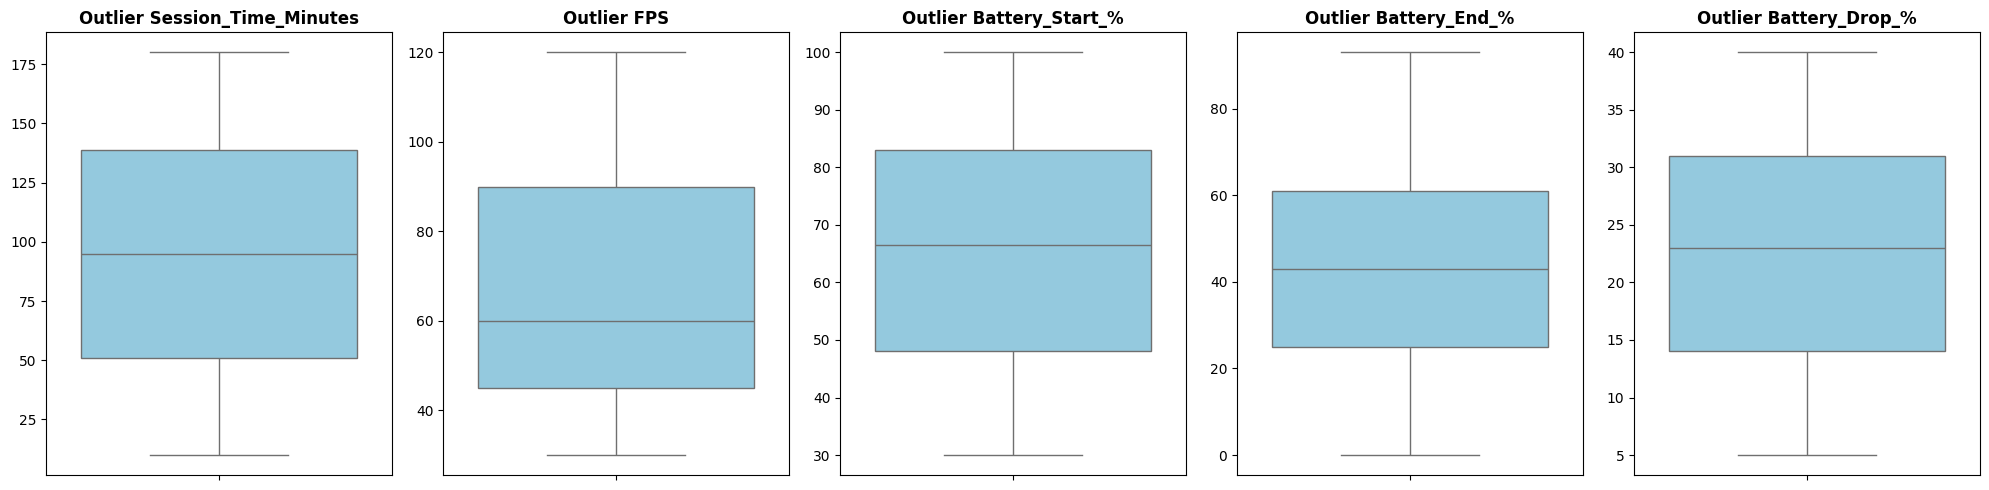

In [18]:
# 1. Pilih hanya kolom yang isinya angka (int atau float)
kolom_angka = df.select_dtypes(include=['float64', 'int64']).columns

# 2. Atur ukuran kanvas gambar (disesuaikan dengan jumlah kolom)
# Misal ada 5 kolom, kita bikin grid 1 baris x 5 kolom berdampingan
fig, axes = plt.subplots(1, len(kolom_angka), figsize=(4 * len(kolom_angka), 5))

# Jika kolomnya cuma 1, pastikan axes berupa list agar tidak eror saat looping
if len(kolom_angka) == 1:
    axes = [axes]

# 3. Looping untuk menggambar boxplot di setiap kolom secara otomatis
for i, kolom in enumerate(kolom_angka):
    sns.boxplot(y=df[kolom],
                ax=axes[i],
                color='skyblue')
    
    axes[i].set_title(f'Outlier {kolom}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Menghilangkan label y agar tidak numpuk

plt.tight_layout()
plt.show()

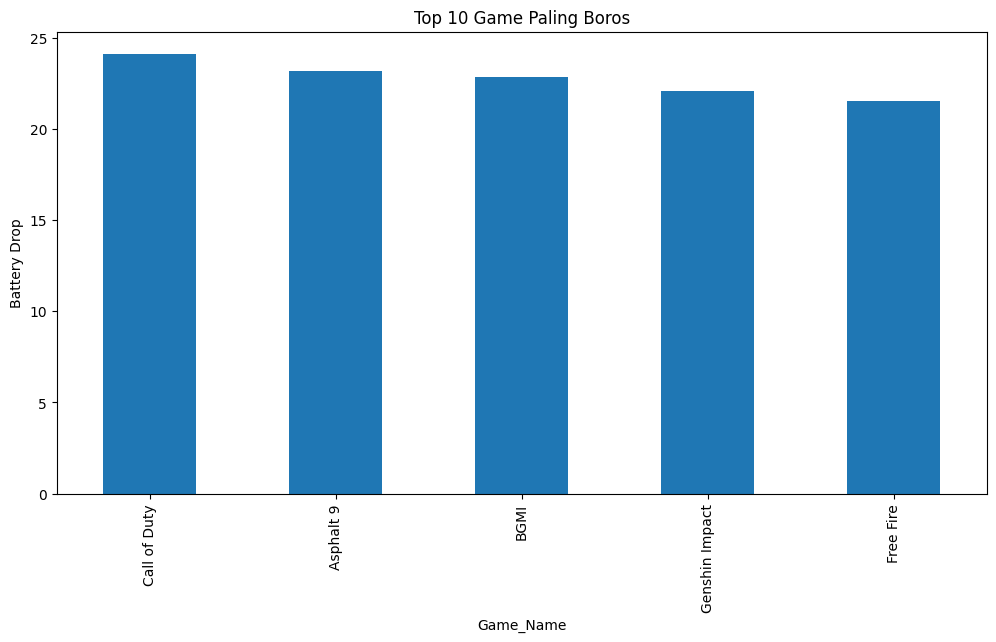

In [ ]:
game_boros = df.groupby('Game_Name')['Battery_Drop_%'].mean().sort_values(ascending=False).head(10)

game_boros.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Top 10 Game Paling Boros")
plt.ylabel("Battery Drop")
plt.show()

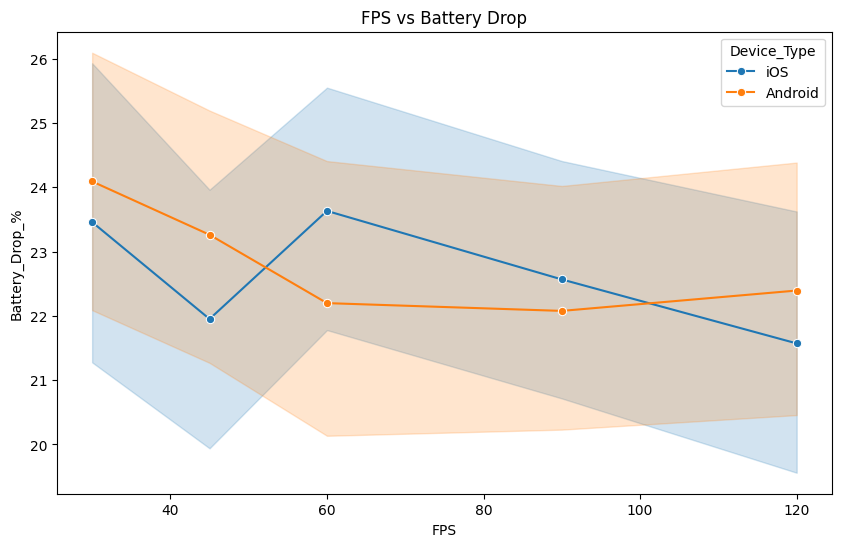

In [ ]:
#cek korelasi fps dengan tingkat pengurangan baterai
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x='FPS',
    y='Battery_Drop_%',
    hue='Device_Type',
    marker='o'
)

plt.title("FPS vs Battery Drop")
plt.show()

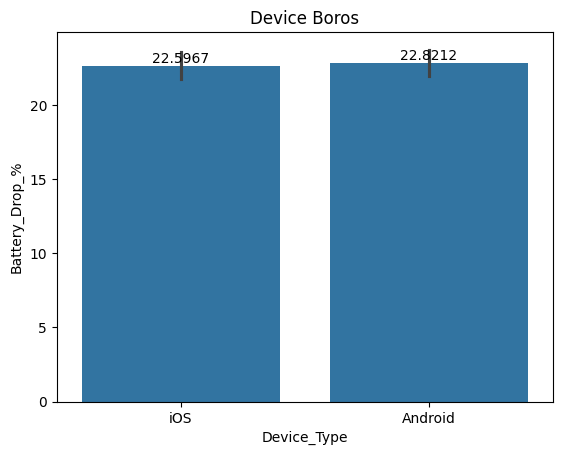

In [ ]:
#cek device mana yang lebih irit    
ax=sns.barplot(data=df,
            x='Device_Type',
            y='Battery_Drop_%',)
for container in ax.containers:
    ax.bar_label(container,
                 label_type='edge')
    
plt.title("Device Boros")
plt.show()

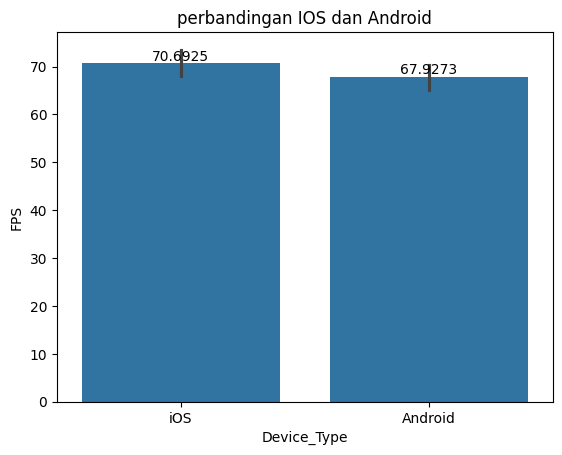

In [ ]:
#cek perbandingan antara ios dan android
plt.Figure(figsize=(10,6))
ax=sns.barplot(data=df,
            x='Device_Type',
            y='FPS'
            )
for container in ax.containers:
    ax.bar_label(container,
                 label_type='edge')
    
plt.title("perbandingan IOS dan Android")
plt.show()

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Game_Name             1000 non-null   str  
 1   Device_Type           1000 non-null   str  
 2   Session_Time_Minutes  1000 non-null   int64
 3   FPS                   1000 non-null   int64
 4   Battery_Start_%       1000 non-null   int64
 5   Battery_End_%         1000 non-null   int64
 6   Battery_Drop_%        1000 non-null   int64
dtypes: int64(5), str(2)
memory usage: 54.8 KB


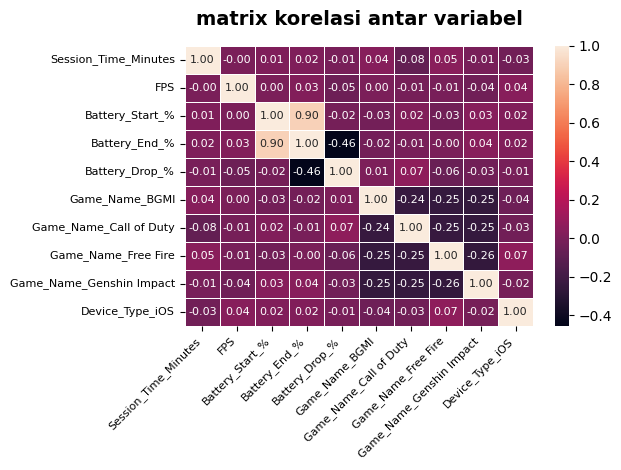

In [39]:
#onehot encoding kolom text
encod=pd.get_dummies(df,columns=['Game_Name','Device_Type'], drop_first=True,dtype=int)

#cek korelasi antar variabel
korelasi=encod.select_dtypes(include=['float64','int64','int32']).corr()
plt.Figure(figsize=(12,10))

sns.heatmap(korelasi,
            annot=True,    #munculin nomor di kotak
            fmt=".2f",
            annot_kws={'size': 8},# sett 2 angka dibelakang koma
            linewidths=0.5)  # ketebalan garis pembatas

plt.xticks(fontsize=8, rotation=45, ha='right') # Ditambah rotasi biar gak tabrakan
plt.yticks(fontsize=8)
plt.title("matrix korelasi antar variabel",fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()